In [1]:
import yfinance as yf

In [2]:
df = yf.download("Reliance.NS",start="2022-03-01",end="2026-03-01")
df.columns = df.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-03-02,1091.369019,1092.483860,1059.813945,1062.202736,21471786
2022-03-03,1082.155151,1098.785820,1078.401303,1092.028893,10186748
2022-03-04,1058.153198,1075.784852,1055.787154,1070.643199,10805667
2022-03-07,1019.022217,1052.033337,1011.036713,1036.835847,17983310
2022-03-08,1017.179321,1021.957023,991.926175,1006.259040,21289374


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-23,1428.000000,1434.900024,1418.300049,1425.000000,7758856
2026-02-24,1428.800049,1433.300049,1415.000000,1425.300049,12529409
2026-02-25,1398.500000,1440.500000,1393.500000,1435.000000,10728792
2026-02-26,1406.800049,1412.900024,1391.900024,1398.500000,16683858
2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440


In [5]:
return_=(df['Close'].shift(-1)-df['Close'])/df['Close']
df['Target']=(return_>0).astype(int)

In [6]:
print(df['Target'].value_counts())
print(df['Target'].head(10))
print(return_.head(10))

Target
1    505
0    484
Name: count, dtype: int64
Date
2022-03-02    0
2022-03-03    0
2022-03-04    0
2022-03-07    0
2022-03-08    1
2022-03-09    1
2022-03-10    1
2022-03-11    1
2022-03-14    0
2022-03-15    1
Name: Target, dtype: int64
Date
2022-03-02   -0.008442
2022-03-03   -0.022180
2022-03-04   -0.036980
2022-03-07   -0.001808
2022-03-08    0.053053
2022-03-09    0.016206
2022-03-10    0.002884
2022-03-11    0.008211
2022-03-14   -0.022903
2022-03-15    0.016882
Name: Close, dtype: float64


In [7]:
df.dropna(inplace=True)
df.shape

(989, 6)

In [8]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

In [9]:
df[['Close','SMA_20','SMA_50']].head(60)

Price,Close,SMA_20,SMA_50
Date,,,
2022-03-02,1091.369019,NaN,NaN
2022-03-03,1082.155151,NaN,NaN
2022-03-04,1058.153198,NaN,NaN
2022-03-07,1019.022217,NaN,NaN
2022-03-08,1017.179321,NaN,NaN
2022-03-09,1071.143799,NaN,NaN
2022-03-10,1088.502441,NaN,NaN
2022-03-11,1091.641968,NaN,NaN
2022-03-14,1100.605591,NaN,NaN


In [10]:
daily_change=df['Close'].diff()
gain=daily_change.clip(lower=0)
loss=daily_change.clip(upper=0).abs()
avg_gain=gain.rolling(14).mean()
avg_loss=loss.rolling(14).mean()
RS=avg_gain/avg_loss
df['RSI']=100-100/(1+RS)

In [11]:
df.head(60)

Price,Close,High,Low,Open,Volume,Target,SMA_20,SMA_50,RSI
Date,,,,,,,,,
2022-03-02,1091.369019,1092.483860,1059.813945,1062.202736,21471786,0,NaN,NaN,NaN
2022-03-03,1082.155151,1098.785820,1078.401303,1092.028893,10186748,0,NaN,NaN,NaN
2022-03-04,1058.153198,1075.784852,1055.787154,1070.643199,10805667,0,NaN,NaN,NaN
2022-03-07,1019.022217,1052.033337,1011.036713,1036.835847,17983310,0,NaN,NaN,NaN
2022-03-08,1017.179321,1021.957023,991.926175,1006.259040,21289374,1,NaN,NaN,NaN
2022-03-09,1071.143799,1077.013475,1016.565078,1017.406956,20414228,1,NaN,NaN,NaN
2022-03-10,1088.502441,1094.303876,1073.828372,1092.028820,17980493,1,NaN,NaN,NaN
2022-03-11,1091.641968,1097.033958,1081.131192,1081.131192,12257423,1,NaN,NaN,NaN
2022-03-14,1100.605591,1103.130983,1080.198330,1086.068005,8340678,0,NaN,NaN,NaN


In [12]:
print(df['RSI'].describe())
print(df['RSI'].head(20))

count    975.000000
mean      51.485638
std       17.083196
min        7.722604
25%       38.741148
50%       52.553386
75%       64.495294
max       97.563393
Name: RSI, dtype: float64
Date
2022-03-02          NaN
2022-03-03          NaN
2022-03-04          NaN
2022-03-07          NaN
2022-03-08          NaN
2022-03-09          NaN
2022-03-10          NaN
2022-03-11          NaN
2022-03-14          NaN
2022-03-15          NaN
2022-03-16          NaN
2022-03-17          NaN
2022-03-21          NaN
2022-03-22          NaN
2022-03-23    61.601950
2022-03-24    66.019023
2022-03-25    72.914590
2022-03-28    86.082318
2022-03-29    86.760454
2022-03-30    84.790036
Name: RSI, dtype: float64


In [13]:
ema_12 = df['Close'].ewm(span=12).mean()
ema_26 = df['Close'].ewm(span=26).mean()

df['MACD'] = ema_12 - ema_26
df['Signal_Line'] = df['MACD'].ewm(span=9).mean()
df['MACD_Histogram'] = df['MACD']-df['Signal_Line']

In [14]:
df[['MACD', 'Signal_Line', 'MACD_Histogram']].head(30)

Price,MACD,Signal_Line,MACD_Histogram
Date,,,
2022-03-02,0.000000,0.000000,0.000000
2022-03-03,-0.206721,-0.114845,-0.091876
2022-03-04,-1.007703,-0.480771,-0.526933
2022-03-07,-2.760118,-1.252907,-1.507211
2022-03-08,-3.727580,-1.989067,-1.738514
2022-03-09,-1.931537,-1.973473,0.041936
2022-03-10,0.039929,-1.463935,1.503863
2022-03-11,1.510530,-0.749115,2.259645
2022-03-14,2.950629,0.105544,2.845084


In [15]:
print(df.columns)
print(df.head(2))

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Target', 'SMA_20', 'SMA_50',
       'RSI', 'MACD', 'Signal_Line', 'MACD_Histogram'],
      dtype='str', name='Price')
Price             Close        High          Low         Open    Volume  \
Date                                                                      
2022-03-02  1091.369019  1092.48386  1059.813945  1062.202736  21471786   
2022-03-03  1082.155151  1098.78582  1078.401303  1092.028893  10186748   

Price       Target  SMA_20  SMA_50  RSI      MACD  Signal_Line  MACD_Histogram  
Date                                                                            
2022-03-02       0     NaN     NaN  NaN  0.000000     0.000000        0.000000  
2022-03-03       0     NaN     NaN  NaN -0.206721    -0.114845       -0.091876  


In [16]:
std_20=df['Close'].rolling(20).std()
df['bb_Upper']=df['SMA_20']+2*std_20
df['bb_Lower']=df['SMA_20']-2*std_20
df['bb_Width']=(df['bb_Upper']-df['bb_Lower'])/df['SMA_20']

In [17]:
df['Momentum']=df['Close']-df['Close'].shift(10)
df['Volatility']=return_.rolling(20).std

In [18]:
df.dropna(inplace=True)
print(df.shape)

(940, 17)


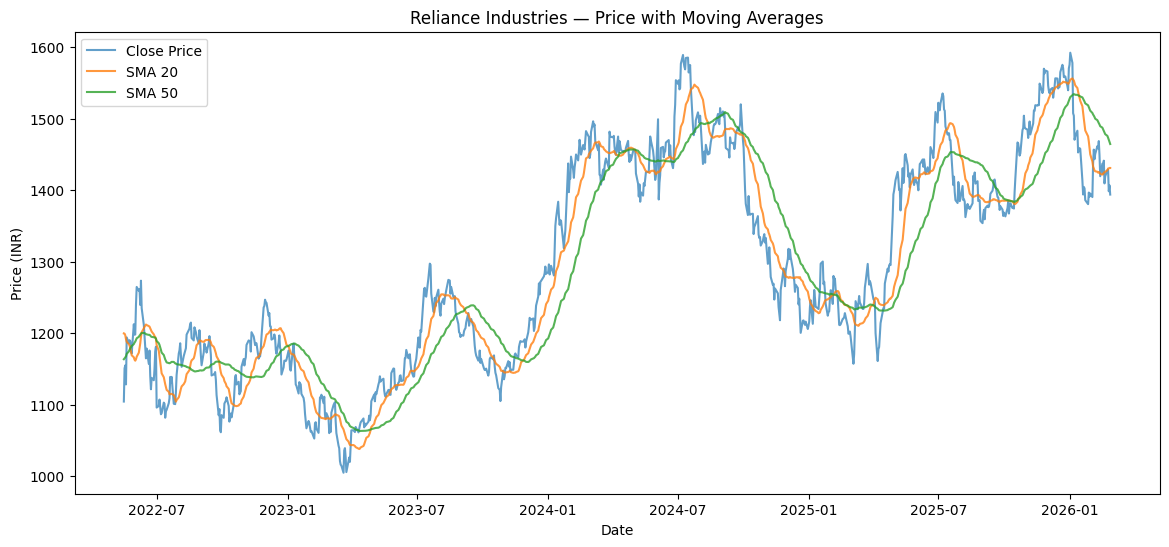

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price', alpha=0.7)
plt.plot(df['SMA_20'], label='SMA 20', alpha=0.8)
plt.plot(df['SMA_50'], label='SMA 50', alpha=0.8)
plt.title('Reliance Industries — Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

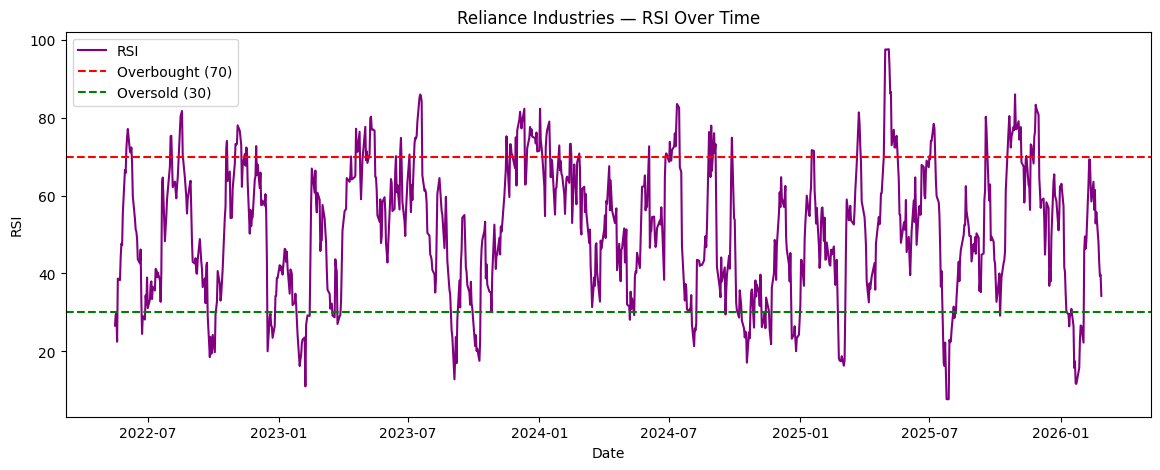

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(df['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title('Reliance Industries — RSI Over Time')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

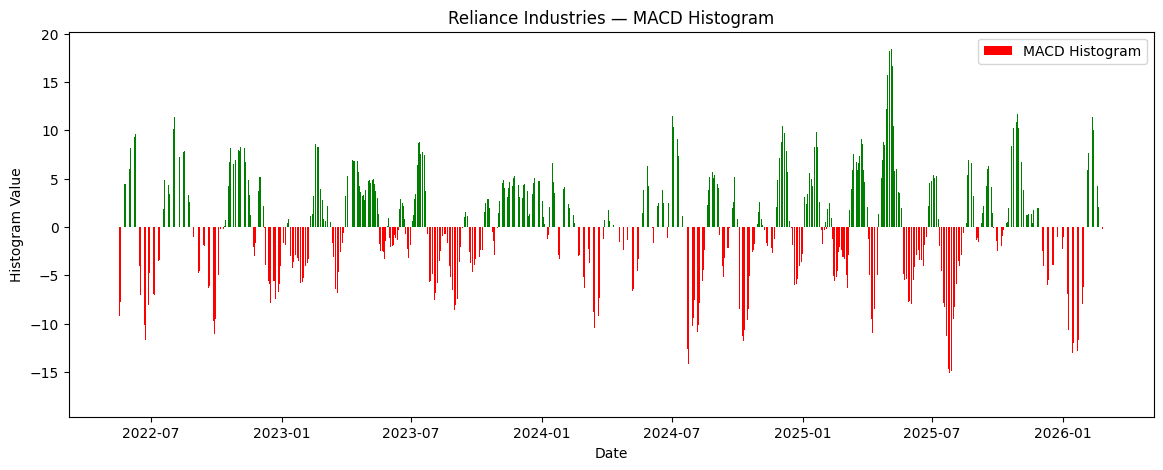

In [21]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['MACD_Histogram'], 
        color=df['MACD_Histogram'].apply(lambda x: 'green' if x > 0 else 'red'),
        label='MACD Histogram')
plt.title('Reliance Industries — MACD Histogram')
plt.xlabel('Date')
plt.ylabel('Histogram Value')
plt.legend()
plt.show()